In [1]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import json
import pathlib
import os
import re
from procompa import get_project_root


PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"

In [3]:
stoic_data = pl.read_csv(data_dir / "Stoic/data_file_stoic.csv")

## Trying to recreate their benchmark


Based on https://www.biorxiv.org/content/10.64898/2026.03.13.711535v1.full.pdf

In [2]:
stoic_data = pl.read_csv(data_dir / "Stoic/data_file_stoic.csv")

train_df = stoic_data.filter(pl.col('split') == 'train')
bench_pool = stoic_data.filter(pl.col('split') == 'benchmark')

In [4]:
# Collect entity cluster IDs from training
train_cluster_ids = set()
for val in train_df['cluster_label'].drop_nulls():
    train_cluster_ids.update(x.strip() for x in val.split(';') if x.strip())


# Valid stoichiometry classes (from STOIC config)
valid_classes = {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 24}

# Filter 1: valid stoichiometry classes
bench = bench_pool.filter(
    pl.col('quantity').map_elements(
        lambda x: all(int(q) in valid_classes for q in str(x).split(':')),
        return_dtype=pl.Boolean
    )
)

In [5]:
# Filter 2: at least one entity cluster not in training
bench = bench.filter(
    pl.col('cluster_label').map_elements(
        lambda x: any(c.strip() not in train_cluster_ids for c in str(x).split(';') if c.strip()),
        return_dtype=pl.Boolean
    )
)

In [6]:
bench = bench.with_columns(
    pl.col('cluster_label').map_elements(
        lambda x: sum(c.strip() in train_cluster_ids for c in str(x).split(';') if c.strip()),
        return_dtype=pl.Int32
    ).alias('n_clusters_in_training')
)

In [ ]:
# Filter 3: best resolution per (cluster_label x quantity)
bench = (
    bench
    .sort('resolution', nulls_last=True)
    .group_by(['cluster_label', 'quantity'])
    .head(1)
)

print(f"Benchmark set: {len(bench)} complexes")
bench.write_csv(data_dir / "Stoic/benchmark_stoic_3335.csv")

Benchmark set: 3335 complexes


## Generate fasta file for stoic benchmark testing

In [7]:
benchmark_stoic = pl.read_csv(data_dir / "Stoic/benchmark_stoic_3335.csv")


In [ ]:
# remove rows, where the seq contains more than 5 consecutive X

benchmark_stoic = benchmark_stoic.filter(
    ~pl.col("sequence")
    .str.split(";")
    .list.eval(pl.element().str.count_matches("X") > 5)
    .list.any()
)

In [ ]:
#splitting benchmark into batches for running stoic in batches

is_zero = pl.col("n_clusters_in_training") == 0

benchmark_stoic_batch = benchmark_stoic.with_columns(
    batch = pl.when(is_zero)
    .then((pl.int_range(pl.len()).over(is_zero) % 12) + 1) # Groups 1-12
    .otherwise((pl.int_range(pl.len()).over(is_zero) % 9) + 13) # Groups 13-21
)
#benchmark_stoic_batch.write_csv(data_dir / "Stoic/batched_benchmark_stoic_3335.csv")

In [ ]:
# match seq to seq_number
stoic_data = pl.read_csv(data_dir / "Stoic/data_file_stoic.csv")

# 1. Expand and Count
df_counts = (
    stoic_data.select([
        pl.col("seq_name").str.split(";"),
        pl.col("sequence").str.split(";")
    ])
    .explode("seq_name")
    .explode("sequence")
    .filter((pl.col("seq_name") != "") & (pl.col("sequence") != ""))
    .group_by(["seq_name", "sequence"])
    .len()
    .sort("len", descending=True) # Highest frequency pairs at the top
)

# 2. Greedy Assignment
# convert to a list of dicts to iterate once. 
seq_map = {}
used_sequences = set()
used_names = set()

for row in df_counts.iter_rows(named=True):
    name = row["seq_name"]
    seq = row["sequence"]
    
    if name not in used_names and seq not in used_sequences:
        seq_map[name] = seq
        used_names.add(name)
        used_sequences.add(seq)

# Safety Check: Was any seq_name missed
all_names = set(
    stoic_data.select(pl.col("seq_name").str.split(";"))
    .explode("seq_name")
    .filter(pl.col("seq_name") != "")
    .unique()["seq_name"]
)

missing = all_names - used_names
if missing:
    print(f"Warning: {len(missing)} names could not be uniquely mapped.")
    # Optional: assign remaining sequences to missing names if any are left
else:
    print(f"Success! All {len(seq_map)} sequences mapped uniquely.")



'''

seq_mapping_df = pl.DataFrame({
    "seq_name": list(seq_map.keys()),
    "sequence": list(seq_map.values())
})

output_path = data_dir / "Stoic/final_seq_name_to_sequence.csv"
seq_mapping_df.write_csv(output_path)

print(f"Saved {len(seq_mapping_df)} unique mappings to {output_path}")
'''

Success! All 133290 sequences mapped uniquely.


In [ ]:
#Create directories with fasta files to run stoic on
#seperate complexes based on overlap in training
df_map = pl.read_csv(data_dir / "Stoic/final_seq_name_to_sequence.csv")
seq_map = dict(zip(df_map["seq_name"], df_map["sequence"]))
os.makedirs(data_dir / "Stoic/benchmark_stoic_batches", exist_ok=True)

for batch_id in benchmark_stoic_batch["batch"].drop_nulls().unique().to_list():
    
    batch_df = benchmark_stoic_batch.filter(pl.col("batch") == batch_id)
    
    batch_dir = data_dir / "Stoic/benchmark_stoic_batches" / f"benchmark_stoic_batch_{batch_id}"
    os.makedirs(batch_dir, exist_ok=True)
    
    for row_idx, row in enumerate(batch_df.iter_rows(named=True)):
        
        pdb_id = row["pdb_id"]
        fasta_path = os.path.join(batch_dir, f"{pdb_id}.fasta")
        
        seq_names = [n.strip() for n in row["seq_name"].split(";") if n.strip()]
        
        # Write out the multi-sequence FASTA file for this complex
        with open(fasta_path, "w") as f:
            for name in seq_names:
                # Retrieve the validated sequence from dictionary
                sequence = seq_map.get(name) 
                
                if sequence:
                    # Standard FASTA format: ">name\nsequence\n"
                    f.write(f">{name}\n{sequence}\n")
                else:
                    print(f"Warning: No valid sequence found in map for '{name}'")

In [ ]:
t =  pl.read_csv(data_dir / "Stoic/final_seq_name_to_sequence.csv").to_dict(as_series=False)


## Analyse Stoic Performance

In [9]:
base_dir = pathlib.Path("../Stoic/stoic_results") 

rows = []

# should find batch_*/complex_name/results.json
json_files = list(base_dir.glob("benchmark_stoic_batch_*/*/results.json"))
print(f"Found {len(json_files)} strictly matched results files to parse...")

for json_path in json_files:
    # Get structural names from folder paths
    complex_name = json_path.parent.name        
    batch_folder = json_path.parent.parent.name 
    
    # Extract the batch number 
    try:
        batch_num = int(re.search(r'\d+', batch_folder).group())
    except Exception:
        batch_num = batch_folder 
        
    try:
        with open(json_path, "r") as f:
            data = json.load(f)
    except Exception as e:
        print(f"Warning: Could not read {json_path}. Skipping. Error: {e}")
        continue
        
    if not data:
        continue
        
    # 3. Extract unique sequence keys (ignoring structural metadata keys)
    first_rank = data[0]
    seq_keys = [k for k in first_rank.keys() if k not in ("rank", "probability")]
    
    sequences_prediction = ";".join(seq_keys)
    
    # 4. Helper function to safely extract predictions per rank
    def extract_rank(rank_idx):
        if rank_idx < len(data):
            rank_dict = data[rank_idx]
            probability = rank_dict.get("probability", None)
            
            # Map values to the exact order found in seq_keys to ensure '5:2:3' matches up
            counts = [str(rank_dict.get(seq, 0)) for seq in seq_keys]
            stoichiometry_format = ":".join(counts)
            
            return stoichiometry_format, probability
        return None, None

    # Pull data for top 3 ranks
    pred_1, prob_1 = extract_rank(0)
    pred_2, prob_2 = extract_rank(1)
    pred_3, prob_3 = extract_rank(2)
    
    rows.append({
        "complex": complex_name,
        "batch": batch_num,
        "sequences_prediction": sequences_prediction,
        "pred_1": pred_1,
        "prob_pred_1": prob_1,
        "pred_2": pred_2,
        "prob_pred_2": prob_2,
        "pred_3": pred_3,
        "prob_pred_3": prob_3
    })


pred_df = pl.DataFrame(rows)

pred_df = pred_df.sort(["batch", "complex"])


output_csv = base_dir.parent / "stoic_pred_summary.csv"
pred_df.write_csv(output_csv)

print(f"\nSuccessfully compiled {len(pred_df)} complexes!")
print(f"Saved summary file to: {output_csv}")


print(pred_df.head(5))

Found 3281 strictly matched results files to parse...

Successfully compiled 3281 complexes!
Saved summary file to: ../Stoic/stoic_pred_summary.csv
shape: (5, 9)
┌─────────┬───────┬─────────────────────┬────────┬───┬────────┬─────────────┬────────┬─────────────┐
│ complex ┆ batch ┆ sequences_predictio ┆ pred_1 ┆ … ┆ pred_2 ┆ prob_pred_2 ┆ pred_3 ┆ prob_pred_3 │
│ ---     ┆ ---   ┆ n                   ┆ ---    ┆   ┆ ---    ┆ ---         ┆ ---    ┆ ---         │
│ str     ┆ i64   ┆ ---                 ┆ str    ┆   ┆ str    ┆ f64         ┆ str    ┆ f64         │
│         ┆       ┆ str                 ┆        ┆   ┆        ┆             ┆        ┆             │
╞═════════╪═══════╪═════════════════════╪════════╪═══╪════════╪═════════════╪════════╪═════════════╡
│ 21wj    ┆ 1     ┆ MDFIKTTKAVRFRLESNNE ┆ 1      ┆ … ┆ 2      ┆ 0.000026    ┆ 24     ┆ 2.4944e-9   │
│         ┆       ┆ NTLIQESINNL…        ┆        ┆   ┆        ┆             ┆        ┆             │
│ 7xrb    ┆ 1     ┆ GMESDPLRGE

In [3]:
#add relevant information (e.g overlap of benchmark complex with the training data) from the original benchmark file to the predictions file
benchmark_stoic_batch = pl.read_csv(data_dir / "Stoic/batched_benchmark_stoic_3335.csv")


cols_to_keep = [
    "pdb_id", 
    "quantity", 
    "sequence", 
    "num_nodes", 
    "num_subunits", 
    "resolution", 
    "n_clusters_in_training",
    "release_date",
    "seq_name",
    "cluster_label"
]
benchmark_subset = benchmark_stoic_batch.select(cols_to_keep)

# 2. Join the dataframes
merged_df = pred_df.join(
    benchmark_subset, 
    left_on="complex", 
    right_on="pdb_id", 
    how="inner"
)

# 3. Define the reordering logic
def reorder_stoichiometry(row):
    seqs_true = row["sequence"].split(";")
    stoic_true = str(row["quantity"]).split(":") 
    
    seqs_pred = row["sequences_prediction"].split(";")
    
    seq_to_count = {seq.strip(): count.strip() for seq, count in zip(seqs_true, stoic_true)}
    reordered_counts = [seq_to_count.get(seq.strip(), "0") for seq in seqs_pred]
    
    return ":".join(reordered_counts)

# 4. Apply the mapping row-by-row
merged_df = merged_df.with_columns(
    pl.struct([
        "sequence", 
        "quantity",
        "sequences_prediction"
    ])
    .map_elements(reorder_stoichiometry, return_dtype=pl.Utf8)
    .alias("stoichiometry_true_reordered")
)

merged_df = merged_df.rename({"sequence": "sequence_og"})
#merged_df.write_csv("../Stoic/prediction_benchmark_stoic_3335.csv")

In [4]:

merged_df = pl.read_csv("../Stoic/prediction_benchmark_stoic_3335.csv")
# 1. Create boolean columns checking if the true stoichiometry is in the top predictions
accuracy_df = merged_df.with_columns(
    (pl.col("pred_1") == pl.col("stoichiometry_true_reordered")).alias("top1_correct"),
    
    ((pl.col("pred_1") == pl.col("stoichiometry_true_reordered")) | 
     (pl.col("pred_2") == pl.col("stoichiometry_true_reordered"))).alias("top2_correct"),
     
    ((pl.col("pred_1") == pl.col("stoichiometry_true_reordered")) | 
     (pl.col("pred_2") == pl.col("stoichiometry_true_reordered")) | 
     (pl.col("pred_3") == pl.col("stoichiometry_true_reordered"))).alias("top3_correct")
)

overall_accuracy = accuracy_df.select([
    (pl.col("top1_correct").mean() * 100).round(2).alias("Top-1 Accuracy (%)"),
    (pl.col("top2_correct").mean() * 100).round(2).alias("Top-2 Accuracy (%)"),
    (pl.col("top3_correct").mean() * 100).round(2).alias("Top-3 Accuracy (%)"),
    pl.len().alias("Total Complexes")
])

print("--- Overall Benchmark Accuracy ---")
print(overall_accuracy)

--- Overall Benchmark Accuracy ---
shape: (1, 4)
┌────────────────────┬────────────────────┬────────────────────┬─────────────────┐
│ Top-1 Accuracy (%) ┆ Top-2 Accuracy (%) ┆ Top-3 Accuracy (%) ┆ Total Complexes │
│ ---                ┆ ---                ┆ ---                ┆ ---             │
│ f64                ┆ f64                ┆ f64                ┆ u32             │
╞════════════════════╪════════════════════╪════════════════════╪═════════════════╡
│ 77.45              ┆ 86.41              ┆ 89.15              ┆ 3281            │
└────────────────────┴────────────────────┴────────────────────┴─────────────────┘


broken down whether it is Homomer/Heteromer

In [ ]:
# Create column labeling Homomer vs Heteromer based on 'num_nodes'
grouped_accuracy = accuracy_df.with_columns(
    pl.when(pl.col("num_nodes") == 1).then(pl.lit("Homomer"))
    .otherwise(pl.lit("Heteromer")).alias("complex_type")
)

# Group by the new label and calculate Top-1 Accuracy
breakdown_df = grouped_accuracy.group_by("complex_type").agg([
    pl.len().alias("Count"),
    (pl.col("top1_correct").mean() * 100).round(2).alias("Top-1 Accuracy (%)")
]).sort("complex_type")

print("\n--- Accuracy by Complex Type ---")
print(breakdown_df)
#grouped_accuracy.write_csv("../Stoic/grouped_accuracy.csv")


--- Accuracy by Complex Type ---
shape: (2, 3)
┌──────────────┬───────┬────────────────────┐
│ complex_type ┆ Count ┆ Top-1 Accuracy (%) │
│ ---          ┆ ---   ┆ ---                │
│ str          ┆ u32   ┆ f64                │
╞══════════════╪═══════╪════════════════════╡
│ Heteromer    ┆ 1637  ┆ 80.02              │
│ Homomer      ┆ 1644  ┆ 74.88              │
└──────────────┴───────┴────────────────────┘


In [ ]:
# generate the summary table
def get_accuracy_summary(df):
    return df.group_by("complex_type").agg([
        (pl.col("top1_correct").mean() * 100).round(2).alias("Top-1 Accuracy (%)"),
        (pl.col("top2_correct").mean() * 100).round(2).alias("Top-2 Accuracy (%)"),
        (pl.col("top3_correct").mean() * 100).round(2).alias("Top-3 Accuracy (%)"),
        pl.len().alias("Total Complexes")
    ]).sort("complex_type")

# Strictly Novel Complexes
overlap_0_df = grouped_accuracy.filter(pl.col("n_clusters_in_training") == 0)
table_overlap_0 = get_accuracy_summary(overlap_0_df)

# Some or total overlap with training set
overlap_not_0_df = grouped_accuracy.filter(pl.col("n_clusters_in_training") != 0)
table_overlap_not_0 = get_accuracy_summary(overlap_not_0_df)


print("=========================================================")
print(" TABLE 1: OVERLAP = 0 (Completely Novel Complexes)")
print("=========================================================")
print(table_overlap_0)

print("\n=========================================================")
print(" TABLE 2: OVERLAP ≠ 0 (Seen/Partially Seen in Training)")
print("=========================================================")
print(table_overlap_not_0)

 TABLE 1: OVERLAP = 0 (Completely Novel Complexes)
shape: (2, 5)
┌──────────────┬────────────────────┬────────────────────┬────────────────────┬─────────────────┐
│ complex_type ┆ Top-1 Accuracy (%) ┆ Top-2 Accuracy (%) ┆ Top-3 Accuracy (%) ┆ Total Complexes │
│ ---          ┆ ---                ┆ ---                ┆ ---                ┆ ---             │
│ str          ┆ f64                ┆ f64                ┆ f64                ┆ u32             │
╞══════════════╪════════════════════╪════════════════════╪════════════════════╪═════════════════╡
│ Heteromer    ┆ 72.67              ┆ 79.0               ┆ 80.67              ┆ 300             │
│ Homomer      ┆ 74.88              ┆ 88.02              ┆ 92.03              ┆ 1644            │
└──────────────┴────────────────────┴────────────────────┴────────────────────┴─────────────────┘

 TABLE 2: OVERLAP ≠ 0 (Seen/Partially Seen in Training)
shape: (1, 5)
┌──────────────┬────────────────────┬────────────────────┬────────────────────┬─

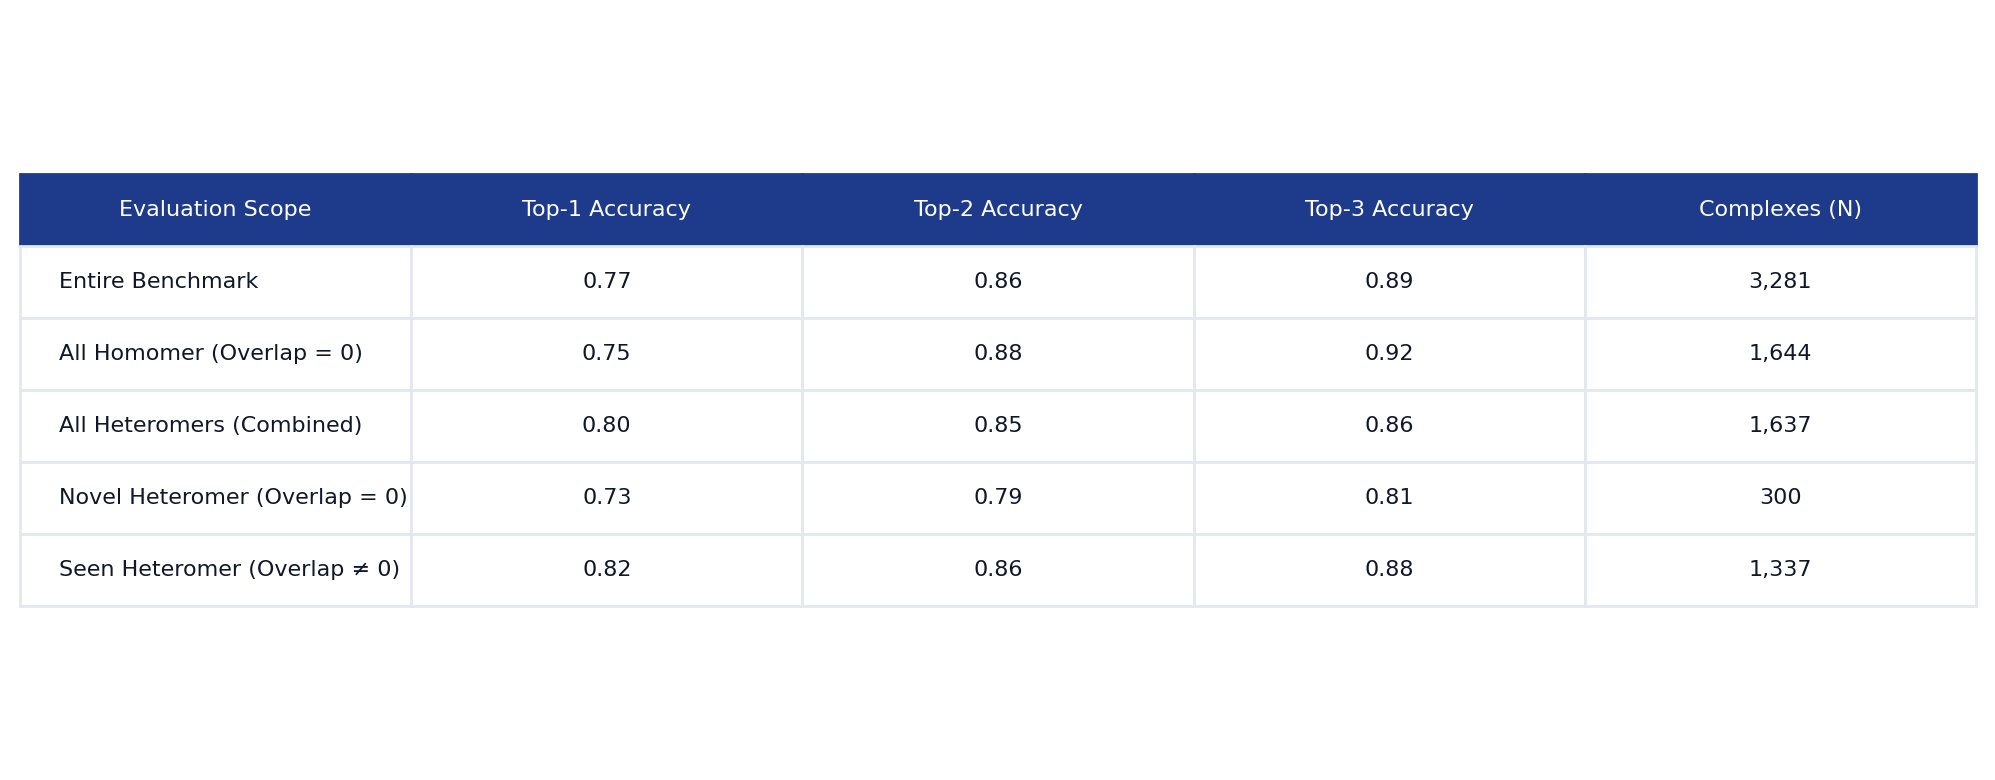

In [10]:
def standardize_cluster(c_str):
    if not c_str or c_str == "None": 
        return ""
    return ";".join(sorted(x.strip() for x in str(c_str).split(";") if x.strip()))


processed_df = accuracy_df.with_columns(
    pl.col("cluster_label").map_elements(standardize_cluster, return_dtype=pl.Utf8).alias("std_cluster"),
    pl.when(pl.col("num_nodes") == 1).then(pl.lit("Homomer")).otherwise(pl.lit("Heteromer")).alias("Architecture")
)


all_homomers = processed_df.filter(pl.col("Architecture") == "Homomer")
novel_homomers = all_homomers.filter(pl.col("n_clusters_in_training") == 0)

all_heteromers = processed_df.filter(pl.col("Architecture") == "Heteromer")
novel_heteromers = all_heteromers.filter(pl.col("n_clusters_in_training") == 0)
seen_heteromers = all_heteromers.filter(pl.col("n_clusters_in_training") != 0)

def get_row_data(df, name):
    if len(df) == 0:
        return [name, "0.0000", "0.0000", "0.0000", "0"]
    t1 = f"{df['top1_correct'].mean():.2f}"
    t2 = f"{df['top2_correct'].mean():.2f}"
    t3 = f"{df['top3_correct'].mean():.2f}"
    n = f"{len(df):,}"
    return [name, t1, t2, t3, n]

columns = ['Evaluation Scope', 'Top-1 Accuracy', 'Top-2 Accuracy', 'Top-3 Accuracy', 'Complexes (N)']
cell_text = [
    get_row_data(processed_df, 'Entire Benchmark'),
    get_row_data(novel_homomers, 'All Homomer (Overlap = 0)'),
    get_row_data(all_heteromers, 'All Heteromers (Combined)'),
    get_row_data(novel_heteromers, 'Novel Heteromer (Overlap = 0)'),
    get_row_data(seen_heteromers, 'Seen Heteromer (Overlap ≠ 0)')
]


fig, ax = plt.subplots(figsize=(10, 4.0), dpi=200)
ax.axis('off') 
fig.patch.set_facecolor('white')

# Construct the table object
table = ax.table(
    cellText=cell_text, 
    colLabels=columns, 
    cellLoc='center', 
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.8)

header_bg = '#1e3a8a'
text_light = '#ffffff'
text_dark = '#0f172a'
nested_bg = '#f8fafc'

for (row, col), cell in table.get_celld().items():
    if row == 0:
 
        cell.set_text_props(color=text_light)
        cell.set_facecolor(header_bg)
        cell.set_edgecolor(header_bg)
    else:
        cell.set_edgecolor('#e2e8f0')
        cell.set_text_props(color=text_dark)
        
        if col == 0:
            cell.set_text_props(ha='left')
            


plt.tight_layout()
plt.show()

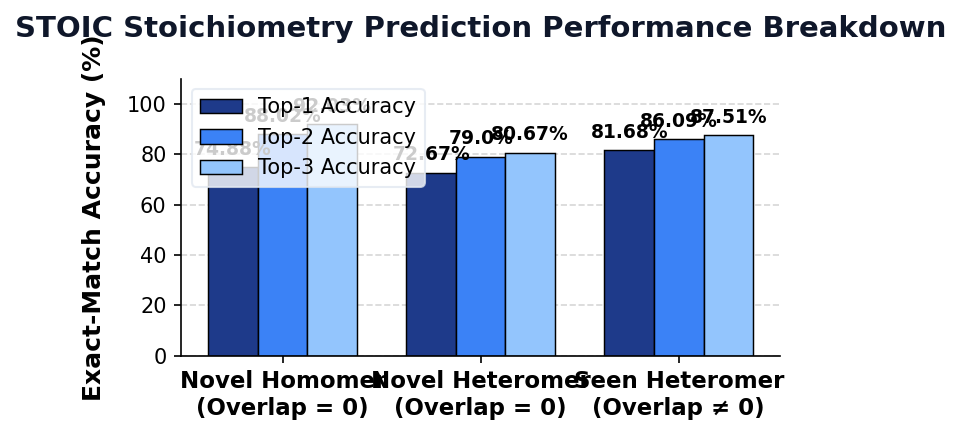

In [13]:
categories = [
    'Novel Homomer\n(Overlap = 0)', 
    'Novel Heteromer\n(Overlap = 0)', 
    'Seen Heteromer\n(Overlap ≠ 0)'
]

top1_accuracy = [74.88, 72.67, 81.68]
top2_accuracy = [88.02, 79.00, 86.09]
top3_accuracy = [92.03, 80.67, 87.51]

x = np.arange(len(categories))  
width = 0.25  

fig, ax = plt.subplots(figsize=(5, 3), dpi=150)
fig.patch.set_facecolor('white')

colors = ['#1e3a8a', '#3b82f6', '#93c5fd'] # Dark Blue, Medium Blue, Light Blue

rects1 = ax.bar(x - width, top1_accuracy, width, label='Top-1 Accuracy', color=colors[0], edgecolor='black', linewidth=0.7)
rects2 = ax.bar(x, top2_accuracy, width, label='Top-2 Accuracy', color=colors[1], edgecolor='black', linewidth=0.7)
rects3 = ax.bar(x + width, top3_accuracy, width, label='Top-3 Accuracy', color=colors[2], edgecolor='black', linewidth=0.7)

ax.set_ylabel('Exact-Match Accuracy (%)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('STOIC Stoichiometry Prediction Performance Breakdown', fontsize=14, fontweight='bold', pad=20, color='#0f172a')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11, fontweight='semibold')
ax.set_ylim(0, 110)  # Give some headroom for labels

ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# 5. Attach text labels on top of each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),  # 4 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='semibold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

ax.legend(frameon=True, facecolor='white', edgecolor='#e2e8f0', loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()


## Does Stoic just predict learned label?

stoichiemetry of each sequence in the Stoic training

In [11]:
train_data = pl.read_csv(data_dir / "Stoic/data_file_stoic.csv").filter(pl.col('split') == 'train')
benchmark_pred = pl.read_csv("../Stoic/grouped_accuracy.csv")

In [12]:
initial_train_count = train_data.height

train_clean = (
    train_data
    .with_columns([
        pl.col("sequence").str.split(";"),
        pl.col("quantity").str.split(":")
    ])
    # Ensure the number of sequences matches the number of quantities
    .filter(pl.col("sequence").list.len() == pl.col("quantity").list.len())
)

print(f"Dropped {initial_train_count - train_clean.height} rows from training data.")

train_counts = (
    train_clean
    .explode(["sequence", "quantity"])
    .group_by(["sequence", "quantity"])
    .agg(pl.len().alias("train_count"))
    .with_columns(
        pl.len().over("sequence").alias("n_different_stoichiometries")
    )
)


Dropped 0 rows from training data.


In [ ]:
#build dataframe that compares benchamrk with training data on sequence level (is the sequence in training, if so with the same stoichiometries, how doe this efefct predction ect.)
# 1: Build a Sequence Lookup Profile from your `train_counts`
# roll up train_counts per sequence to get totals and its historical quantities
train_profile = (
    train_counts
    .group_by("sequence")
    .agg([
        # Total times this sequence appeared in training across all structures
        pl.col("train_count").sum().alias("total_train_count"),
        
        # quantities this sequence held in training 
        pl.col("quantity").unique().alias("train_quantities_list"),
        
        #  how often each stoichiometry was present in training
        (pl.col("quantity") + " (x" + pl.col("train_count").cast(pl.Utf8) + ")")
        .str.concat(", ")
        .alias("train_stoichiometry_distribution")
    ])
)


# 2: Flatten the Benchmark Dataframe (Parallel Explode)
bench_flat = (
    benchmark_pred
    .with_columns([
        pl.col("sequences_prediction").str.split(";").alias("sequence"),
        pl.col("pred_1").str.split(":"),
        pl.col("pred_2").str.split(":"),
        pl.col("pred_3").str.split(":"),
        pl.col("stoichiometry_true_reordered").str.split(":").alias("true_stoi")
    ])
    .explode(["sequence", "pred_1", "pred_2", "pred_3", "true_stoi"])
)


#3: Map Training Data & Calculate Core Target Indicators
detailed_analysis = (
    bench_flat
    .join(train_profile, on="sequence", how="left")
    .with_columns([
  
        pl.col("total_train_count").is_not_null().alias("seen_in_train"),
        
        #identify sequences completely new to the model
        pl.col("total_train_count").fill_null(0),
        pl.col("train_stoichiometry_distribution").fill_null("Never seen in training"),
        
        # benchmark truth is present anywhere in the sequence's training list
        pl.col("train_quantities_list")
        .list.contains(pl.col("true_stoi"))
        .fill_null(False)
        .alias("same_quantity_as_train")
    ])
    .with_columns([
        # Are the individual predictions correct?
        (pl.col("pred_1") == pl.col("true_stoi")).fill_null(False).alias("pred_1_correct"),
        (pl.col("pred_2") == pl.col("true_stoi")).fill_null(False).alias("pred_2_correct"),
        (pl.col("pred_3") == pl.col("true_stoi")).fill_null(False).alias("pred_3_correct")
    ])
    .drop("train_quantities_list")
)

#detailed_analysis.write_csv("../Stoic/detailed_prediction_results_analysis.csv")

/tmp/ipykernel_882174/2526338280.py:19: DeprecationWarning: `str.concat` is deprecated; use `str.join` instead. Note also that the default `delimiter` for `str.join` is an empty string, not a hyphen.
  .str.concat(", ")


shape: (5, 13)
┌────────────┬────────────┬────────────┬────────────┬───┬────────┬────────────┬────────┬───────────┐
│ sequence   ┆ complex_ty ┆ seen_in_tr ┆ total_trai ┆ … ┆ pred_2 ┆ pred_2_cor ┆ pred_3 ┆ pred_3_co │
│ ---        ┆ pe         ┆ ain        ┆ n_count    ┆   ┆ ---    ┆ rect       ┆ ---    ┆ rrect     │
│ str        ┆ ---        ┆ ---        ┆ ---        ┆   ┆ str    ┆ ---        ┆ str    ┆ ---       │
│            ┆ str        ┆ bool       ┆ u32        ┆   ┆        ┆ bool       ┆        ┆ bool      │
╞════════════╪════════════╪════════════╪════════════╪═══╪════════╪════════════╪════════╪═══════════╡
│ MAGSKVDKTL ┆ Homomer    ┆ false      ┆ 0          ┆ … ┆ 2      ┆ false      ┆ 1      ┆ false     │
│ CRLGDITGLL ┆            ┆            ┆            ┆   ┆        ┆            ┆        ┆           │
│ IVLSVLVSRG ┆            ┆            ┆            ┆   ┆        ┆            ┆        ┆           │
│ …          ┆            ┆            ┆            ┆   ┆        ┆          

In [ ]:
# Build table that reports performance across different categories (whether there is overlap in training/ stoichiometry is new/ homomer or heteromer) on seqeunce level
category_specs = [
    ("Entire Benchmark\n(All evaluation samples)", pl.lit(True)),
    ("All Homomers", pl.col("complex_type") == "Homomer"),
    ("All Heteromers", pl.col("complex_type") == "Heteromer"),
    ("Sequence Not in Training", pl.col("seen_in_train") == False),
    ("Sequence in Training\n(Stoichiometry was ALREADY seen in training)", 
     (pl.col("seen_in_train") == True) & (pl.col("same_quantity_as_train") == True)),
    ("Sequence in Training\n(Stoichiometry is NOVEL compared to training)", 
     (pl.col("seen_in_train") == True) & (pl.col("same_quantity_as_train") == False))
]

summary_rows = []

for name, condition in category_specs:
    row_metrics = (
        detailed_analysis
        .filter(condition)
        .select([
            pl.lit(name).alias("category"),
            pl.len().alias("n_predictions"),
            pl.col("sequence").n_unique().alias("unique_sequences"),
            
            # Cumulative accuracy metrics (Maximal accuracy if taking up to K guesses)
            (pl.col("pred_1_correct").mean() ).round(2).alias("top1_accuracy"),
            ((pl.col("pred_1_correct") | pl.col("pred_2_correct")).mean()).round(2).alias("top2_accuracy"),
            ((pl.col("pred_1_correct") | pl.col("pred_2_correct") | pl.col("pred_3_correct")).mean()).round(2).alias("top3_accuracy")
        ])
    )
    summary_rows.append(row_metrics)

category_summary = pl.concat(summary_rows)

print("--- Text Table Output ---")
print(category_summary)



table_rows = []
for r in category_summary.iter_rows(named=True):
    table_rows.append([
        r["category"],
        f"{r['n_predictions']:,}",
        f"{r['unique_sequences']:,}",
        f"{r['top1_accuracy']:.2f}" if r['n_predictions'] > 0 else "-",
        f"{r['top2_accuracy']:.2f}" if r['n_predictions'] > 0 else "-",
        f"{r['top3_accuracy']:.2f}" if r['n_predictions'] > 0 else "-"
    ])

headers = ["Evaluation Category", "N Predictions\n(Total Rows)", "Unique\nSequences", "Top-1 Acc", "Top-2 Acc", "Top-3 Acc"]



fig, ax = plt.subplots(figsize=(15, 6.5), dpi=300)
ax.axis('off')

col_widths = [0.46, 0.12, 0.10, 0.11, 0.11, 0.11]

table = ax.table(
    cellText=table_rows, 
    colLabels=headers, 
    cellLoc='center', 
    colWidths=col_widths,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10.5)  
table.scale(1.0, 3.2)     

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#d9d9d9')
    
    if row == 0:
        cell.set_text_props(weight='bold', color='white', va='center')
        cell.set_facecolor('#1f4e79') 
    else:
        if col == 0:
            cell.set_text_props(ha='left', va='center')
        else:
            cell.set_text_props(ha='center', va='center')
        
        if row == 6:
            cell.set_facecolor('#fff2cc') # Soft light amber alert box
            cell.set_text_props(weight='bold')

plt.savefig("../Stoic/figures/stoic_comprehensive_summary.png", bbox_inches='tight', pad_inches=0.3, transparent=True)
plt.savefig("../Stoic/figures/stoic_comprehensive_summary.pdf", bbox_inches='tight', pad_inches=0.3, transparent=True)
plt.close()

print("\nSuccessfully generated 'stoic_comprehensive_summary.png'!")

--- Text Table Output ---
shape: (6, 6)
┌─────────────────┬───────────────┬────────────────┬───────────────┬───────────────┬───────────────┐
│ category        ┆ n_predictions ┆ unique_sequenc ┆ top1_accuracy ┆ top2_accuracy ┆ top3_accuracy │
│ ---             ┆ ---           ┆ es             ┆ ---           ┆ ---           ┆ ---           │
│ str             ┆ u32           ┆ ---            ┆ f64           ┆ f64           ┆ f64           │
│                 ┆               ┆ u32            ┆               ┆               ┆               │
╞═════════════════╪═══════════════╪════════════════╪═══════════════╪═══════════════╪═══════════════╡
│ Entire          ┆ 11247         ┆ 6766           ┆ 0.89          ┆ 0.93          ┆ 0.94          │
│ Benchmark       ┆               ┆                ┆               ┆               ┆               │
│ (All evaluati…  ┆               ┆                ┆               ┆               ┆               │
│ All Homomers    ┆ 1644          ┆ 1571           

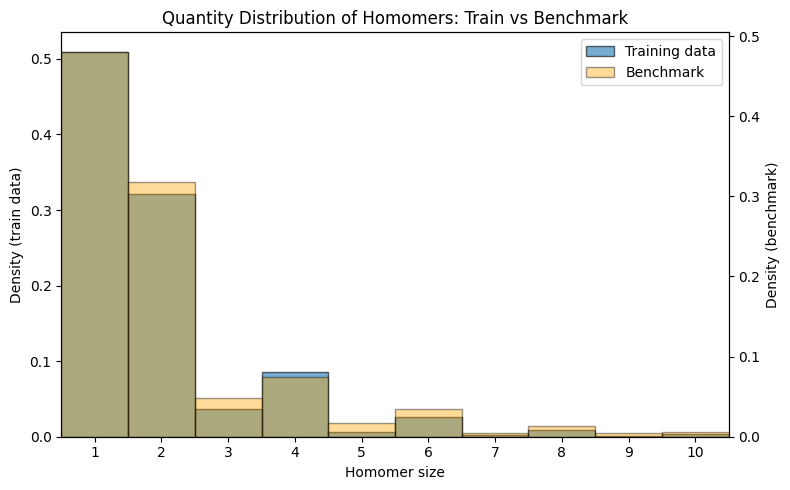

In [ ]:
# plot Quantity Distribution of Homomer size: Train vs Benchmark
data_left = (
    train_data
    .filter(pl.col("num_nodes") == 1)["quantity"]
    .cast(pl.Int64)
    .to_list()
)

data_right = (
    detailed_analysis
    .filter(pl.col("complex_type") == "Homomer")["quantity"]
    .cast(pl.Int64)
    .to_list()
)

data_left = [x for x in data_left if 1 <= x <= 10]
data_right = [x for x in data_right if 1 <= x <= 10]

bins = np.arange(0.5, 10.5 + 1, 1)

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.hist(
    data_left,
    bins=bins,
    density=True,
    edgecolor='black',
    alpha=0.6,
    label="Training data"
)
ax1.set_xlabel("Homomer size")
ax1.set_ylabel("Density (train data)")

ax2 = ax1.twinx()

ax2.hist(
    data_right,
    bins=bins,
    density=True,
    edgecolor='black',
    alpha=0.4,
    color='orange',
    label="Benchmark"
)
ax2.set_ylabel("Density (benchmark)")

ax1.set_xlim(0.5, 10.5)
ax1.set_xticks(range(1, 11))

plt.title("Quantity Distribution of Homomers: Train vs Benchmark")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

what is the avergae complex size of homomers

In [2]:
detailed_analysis = pl.read_csv("../Stoic/detailed_prediction_results_analysis.csv")

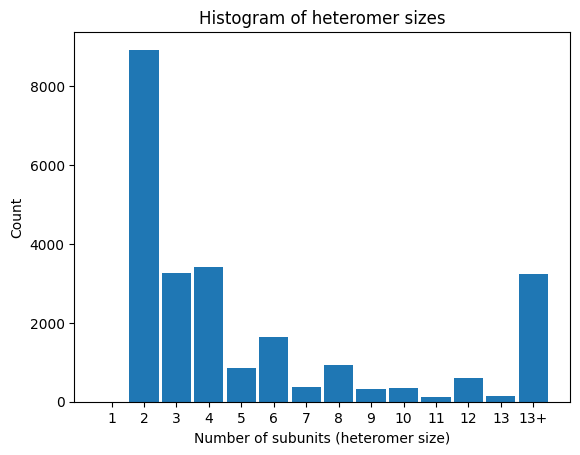

In [ ]:
#histogramm for heteromer size

heteromer_size = (
    train_data
    .filter(pl.col("num_nodes") > 1)["num_subunits"]
    .cast(pl.Int64)
    .to_list()
)

heteromer_size_capped = [x if x <= 13 else 14 for x in heteromer_size]

bins = np.arange(1, 16)  

plt.figure()
plt.hist(heteromer_size_capped, bins=bins, align="left", rwidth=0.9)

plt.xlabel("Number of subunits (heteromer size)")
plt.ylabel("Count")
plt.title("Histogram of heteromer sizes")

plt.xticks(
    ticks=list(range(1, 15)),
    labels=[str(i) for i in range(1, 14)] + ["13+"]
)

plt.show()

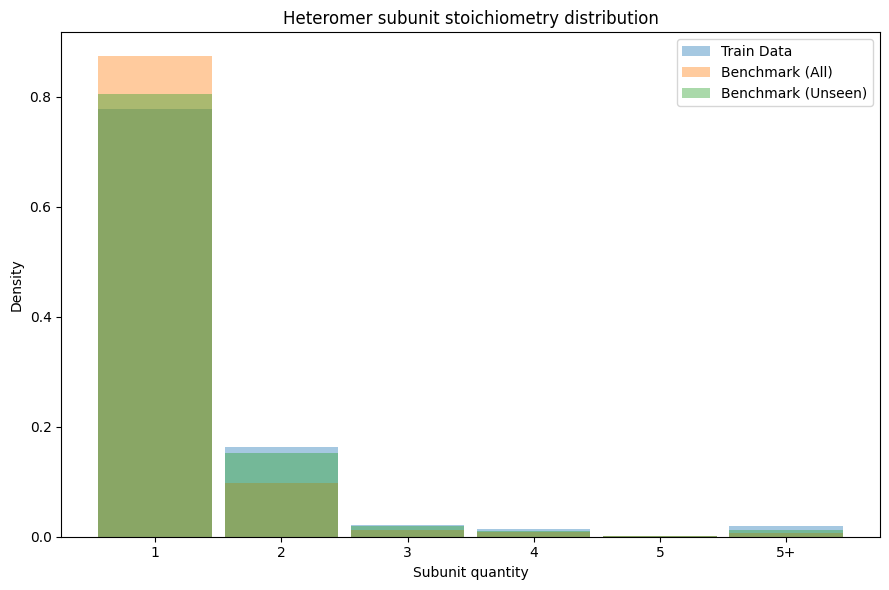

In [ ]:
# heteromer quantity distribution between diff subsets
heteromer_subunit_quantity = (
    train_data
    .filter(pl.col("num_nodes") > 1)
    .select(
        pl.col("quantity")
        .str.split(":")
        .list.eval(pl.element().cast(pl.Int64))
    )
    .explode("quantity")
    .to_series()
    .to_list()
)

train_capped = [x if x <= 5 else 6 for x in heteromer_subunit_quantity]

benchmark_heteromer_quantity = (
    detailed_analysis
    .filter(pl.col("complex_type") == "Heteromer")
    .select(
        pl.col("quantity")
        .str.split(":")
        .list.eval(pl.element().cast(pl.Int64))
    )
    .explode("quantity")
    .to_series()
    .to_list()
)

benchmark_capped = [x if x <= 5 else 6 for x in benchmark_heteromer_quantity]


unknown_benchmark_sequence = (
    detailed_analysis
    .filter(
        (pl.col("complex_type") == "Heteromer") & 
        (pl.col("seen_in_train") == False)
    )
    .select(
        pl.col("quantity")
        .str.split(":")
        .list.eval(pl.element().cast(pl.Int64))
    )
    .explode("quantity")
    .to_series()
    .to_list()
)

unknown_capped = [x if x <= 5 else 6 for x in unknown_benchmark_sequence]


bins = np.arange(1, 8) 

plt.figure(figsize=(9, 6))

# Histogram 1: Train Data
plt.hist(
    train_capped,
    bins=bins,
    align="left",
    rwidth=0.9,
    density=True,
    alpha=0.4,
    label="Train Data",
    color="tab:blue"
)

# Histogram 2: All Benchmark Data
plt.hist(
    benchmark_capped,
    bins=bins,
    align="left",
    rwidth=0.9,
    density=True,
    alpha=0.4,
    label="Benchmark (All)",
    color="tab:orange"
)

# Histogram 3: Unknown Benchmark Data
plt.hist(
    unknown_capped,
    bins=bins,
    align="left",
    rwidth=0.9,
    density=True,
    alpha=0.4,
    label="Benchmark (Unseen)",
    color="tab:green"
)

plt.xlabel("Subunit quantity")
plt.ylabel("Density")
plt.title("Heteromer subunit stoichiometry distribution")

plt.xticks(
    ticks=list(range(1, 7)),
    labels=["1", "2", "3", "4", "5", "5+"]
)
plt.legend()

plt.tight_layout()
plt.show()

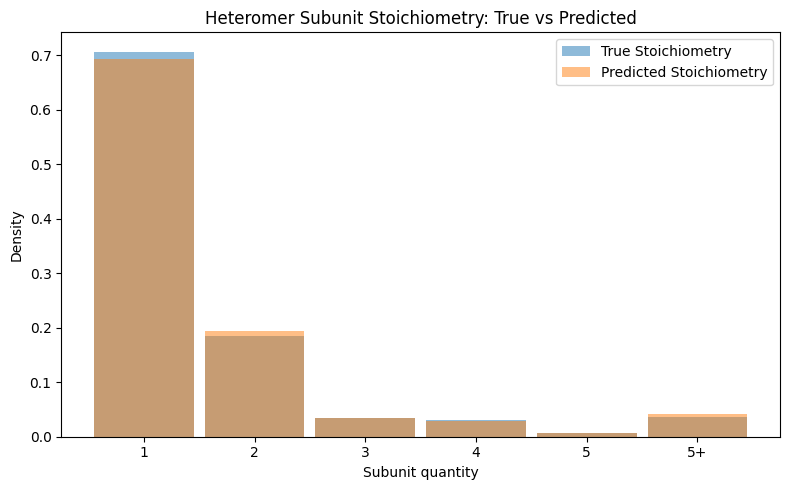

In [ ]:
# do the distribution of predicted and benchmark heteromers? look the sam 
# Further question does it match the training sistribution?
def extract_and_flatten(df, col_name):
    return (
        df.select(
            pl.col(col_name)
            .cast(pl.String)          
            .str.split(":")          
            .list.eval(pl.element().cast(pl.Int64))
        )
        .explode(col_name)            
        .get_column(col_name)
        .drop_nulls()                 
        .to_list()
    )


true_soi_raw = extract_and_flatten(detailed_analysis, "true_stoi")
pred_raw = extract_and_flatten(detailed_analysis, "pred_1")

true_capped = [x if x <= 5 else 6 for x in true_soi_raw]
pred_capped = [x if x <= 5 else 6 for x in pred_raw]

bins = np.arange(1, 8)  

plt.figure(figsize=(8, 5))

# Plot True Values
plt.hist(
    true_capped,
    bins=bins,
    align="left",
    rwidth=0.9,
    density=True,
    alpha=0.5,
    label="True Stoichiometry",
    color="tab:blue"
)

# Plot Predicted Values
plt.hist(
    pred_capped,
    bins=bins,
    align="left",
    rwidth=0.9,
    density=True,
    alpha=0.5,
    label="Predicted Stoichiometry",
    color="tab:orange"
)

# Formatting
plt.xlabel("Subunit quantity")
plt.ylabel("Density")
plt.title("Heteromer Subunit Stoichiometry: True vs Predicted")
plt.xticks(
    ticks=list(range(1, 7)),
    labels=["1", "2", "3", "4", "5", "5+"]
)
plt.legend()

plt.tight_layout()
plt.show()